In [1]:
import torch 

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [2]:
import numpy as np
import matplotlib.pyplot as plt 

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [3]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2 

model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2_checkpoint = "checkpoints/sam2.1_hiera_large.pt"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)


In [9]:
rutaImagen = "../lobos_marinos2.jpg"
image = cv2.imread(rutaImagen)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image) # Image Encoder

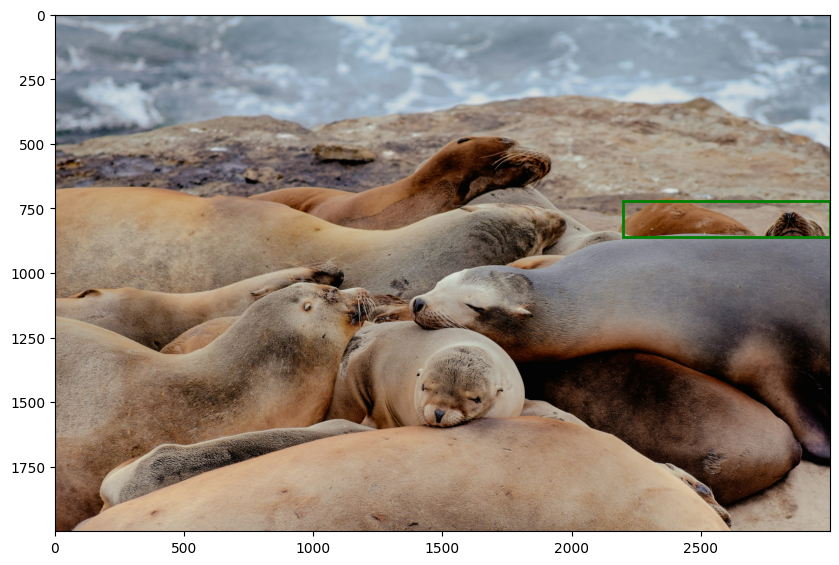

In [18]:
# david.jpg
#input_point = np.array([[650, 200], [610, 50], [600, 400], [800, 700]]) # (x, y)
#input_label = np.array([1, 1, 0, 1])
#input_point = np.array([[450, 150]]) # (x, y)
input_label = np.array([1])
input_box = np.array([2200, 720, 3000, 860]) # xyxy


plt.figure(figsize=(10, 10))
plt.imshow(image)
#show_points(input_point, input_label, plt.gca())
show_box(input_box, plt.gca())
plt.axis('on')
plt.show()

In [19]:
masks, scores, logits = predictor.predict(
    #point_coords=input_point,
    box=input_box,
    point_labels=input_label,
    multimask_output=True
)

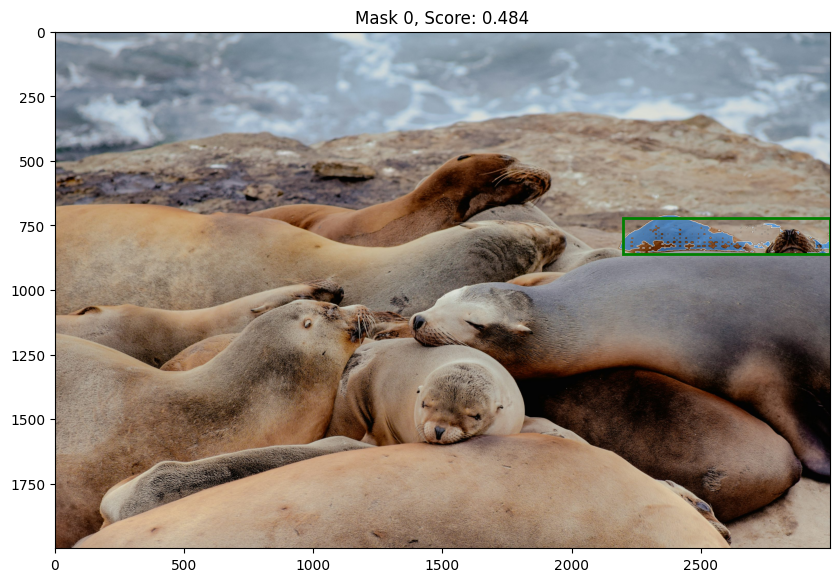

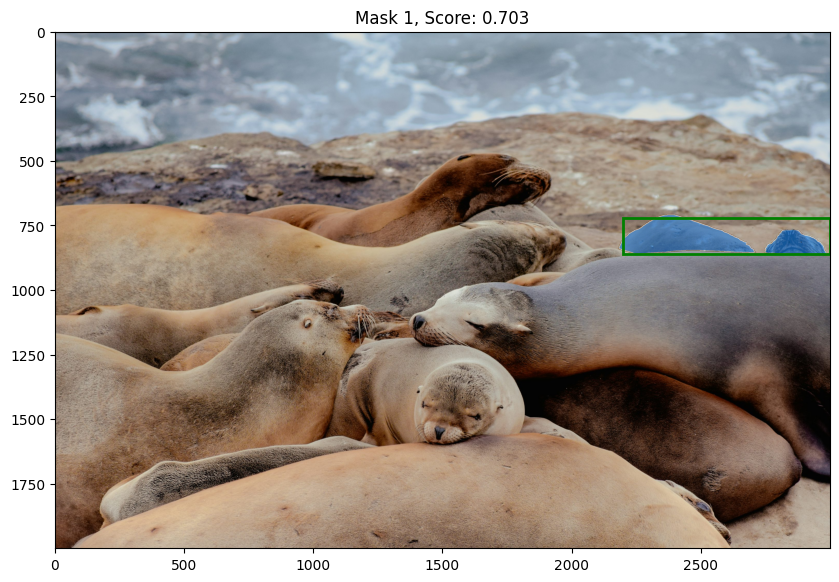

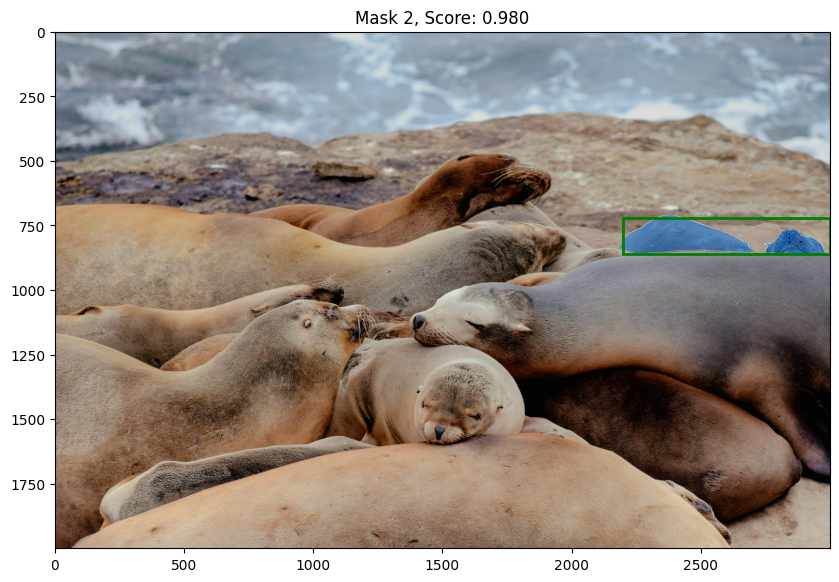

In [20]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    #show_points(input_point, input_label, plt.gca())
    show_box(input_box, plt.gca())
    plt.title(f"Mask {i}, Score: {score:.3f}")
    plt.axis('on')
    plt.show()

In [28]:
input_boxes = np.array([[2200, 720, 3000, 860],
                        [1000, 1100, 1800, 1600]]) # xyxy

masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_boxes,
    multimask_output=False
)

In [29]:
masks.shape

(2, 1, 2000, 3000)

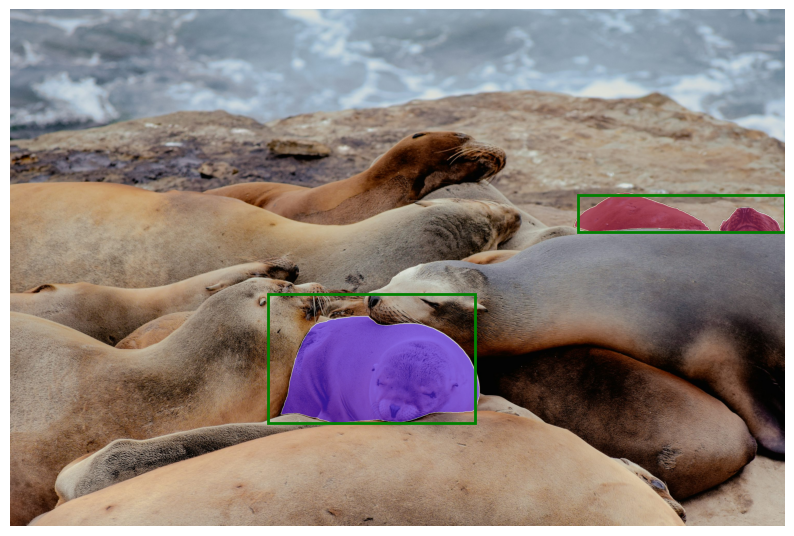

In [30]:
plt.figure(figsize=(10, 10))
plt.imshow(image)

for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)

for box in input_boxes:
    show_box(box, plt.gca())

plt.axis('off')
plt.show()

In [31]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

mask_generator = SAM2AutomaticMaskGenerator(sam2_model)

In [85]:
rutaImagen2 = "../rayos_x2.png"
image2 = cv2.imread(rutaImagen2)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image2)

In [86]:
print(len(masks))

7


In [87]:
print(masks[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


In [88]:
def show_anns(anns, borders=True, n_top_area=None):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    if n_top_area is not None:
        sorted_anns = sorted_anns[:n_top_area]
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

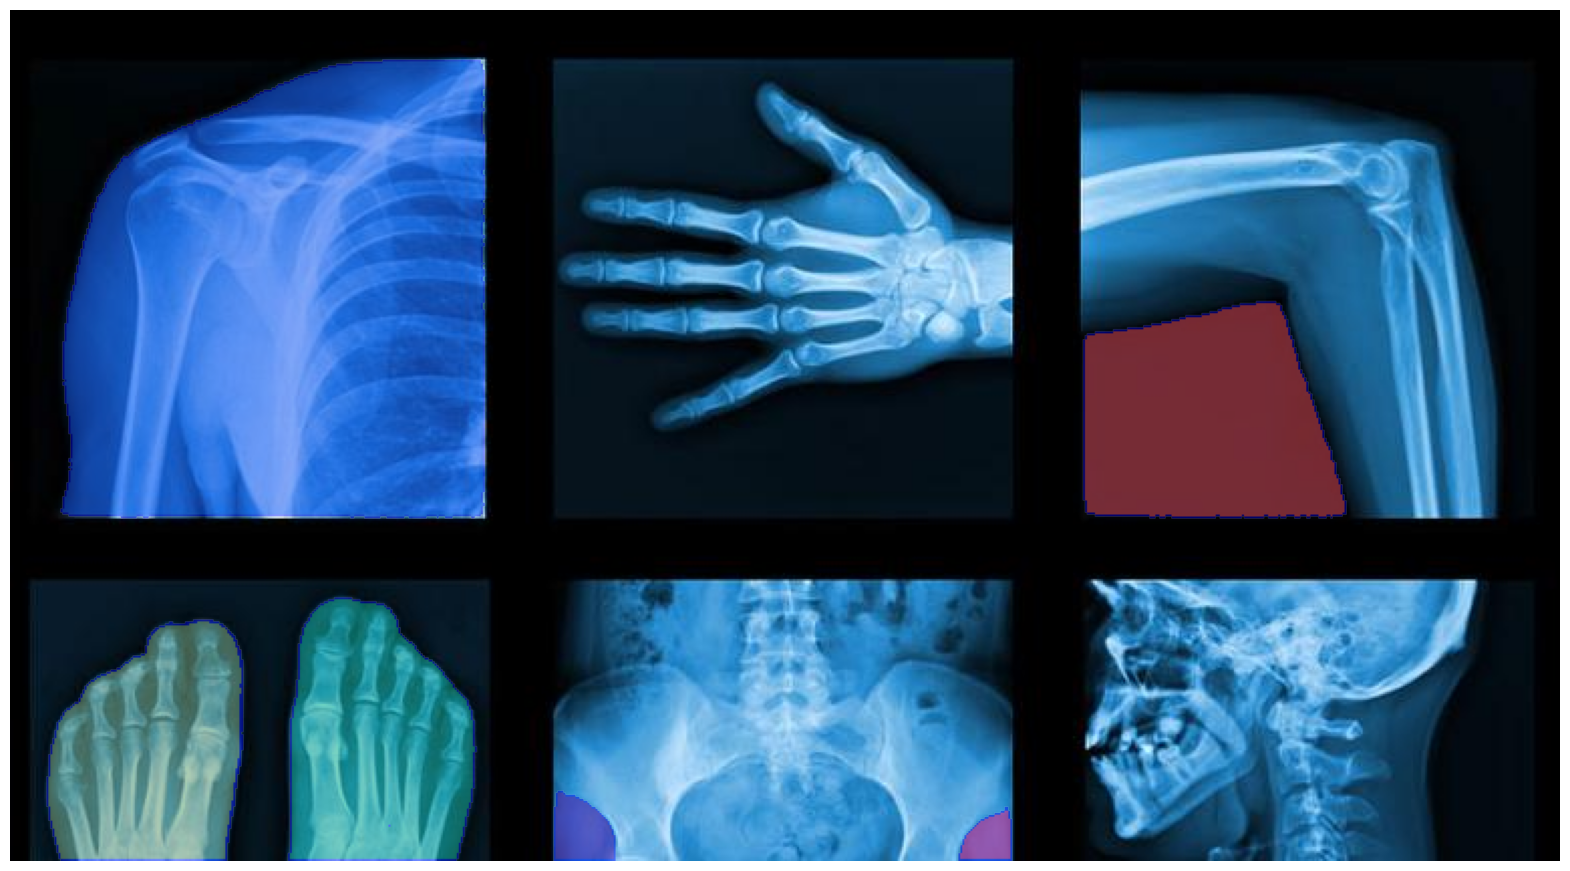

In [89]:
plt.figure(figsize=(20, 20))
plt.imshow(image2)
show_anns(masks, True)
plt.axis('off')
plt.show()

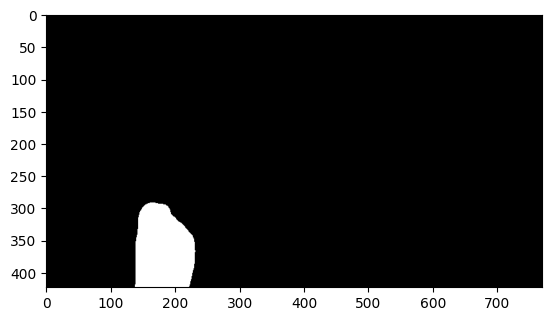

In [99]:
plt.imshow(masks[2]['segmentation'], cmap='gray')